In [2]:
%pip install numpy
%pip install matplotlib
%pip install scipy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import ode

In [3]:
x0 = 0.0
y0 = 0.0

In [4]:
g = 9.8

In [10]:
def solve(v0: float, alpha: float, k1: float, k2: float, max_t: float = None) -> tuple[np.ndarray, np.ndarray, float, float, float]:
    vx0 = v0 * np.cos(alpha)
    vy0 = v0 * np.sin(alpha)

    dt = 0.01

    xs = []
    ys = []

    integrator = ode(lambda _, state: np.array([
        state[2], 
        state[3], 
        -k1 * state[2] - k2 * state[2] * np.linalg.norm([state[2], state[3]]), 
        -g - k1 * state[3] - k2 * state[2] * np.linalg.norm([state[2], state[3]])
    ]))
    integrator.set_initial_value(np.array([x0, y0, vx0, vy0]))

    y_was_positive = True
    flight_distance = 0
    flight_time = 0
    while integrator.successful() and (max_t is None or integrator.t < max_t):
        state = integrator.integrate(integrator.t + dt)
        xs.append(state[0])
        ys.append(state[1])

        if state[1] <= 0 and y_was_positive:
            flight_distance = state[0]
            flight_time = integrator.t
            y_was_positive = False
            if max_t is None:
                break

    xs = np.array(xs)
    ys = np.array(ys)

    return (xs, ys, flight_distance, flight_time, np.max(ys))

In [12]:
no_resistance = solve(50, np.pi / 4, 0, 0, 8)
linear_resistance = solve(50, np.pi / 4, 0.01, 0, 8)
quadratic_resistance = solve(50, np.pi / 4, 0, 0.0005, 8)

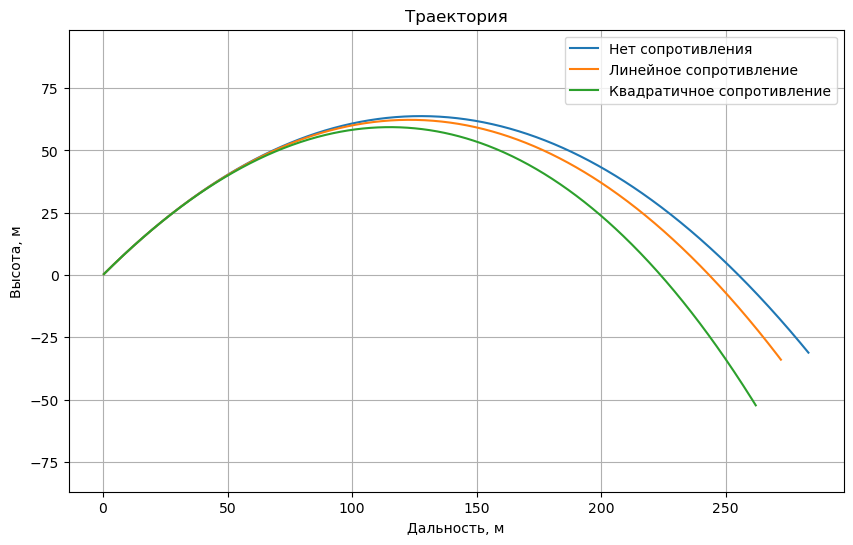

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(no_resistance[0], no_resistance[1], label='Нет сопротивления')
plt.plot(linear_resistance[0], linear_resistance[1], label='Линейное сопротивление')
plt.plot(quadratic_resistance[0], quadratic_resistance[1], label='Квадратичное сопротивление')

plt.title('Траектория')
plt.xlabel('Дальность, м')
plt.ylabel('Высота, м')
plt.legend()
plt.grid(True)
plt.axis('equal') 
plt.show()

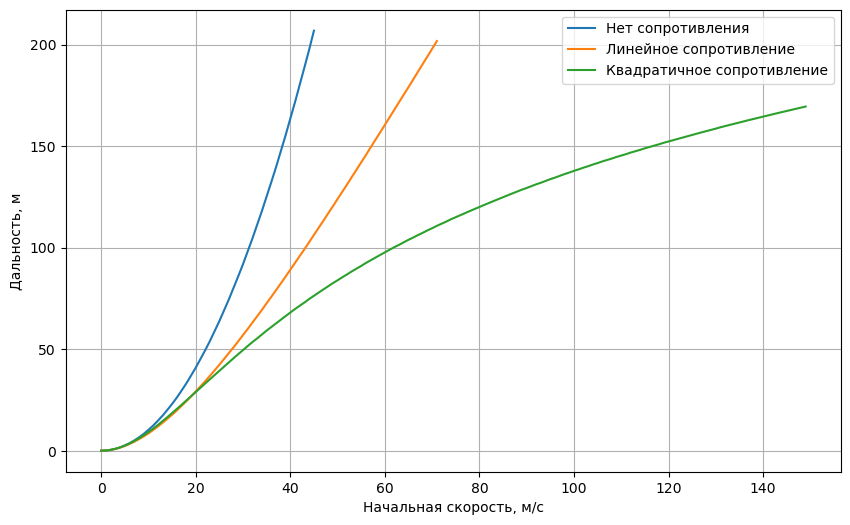

In [18]:
plt.figure(figsize=(10, 6))

for (k1, k2, name) in [(0.0, 0.0, 'Нет сопротивления'), (0.2, 0.0, 'Линейное сопротивление'), (0.0, 0.01, 'Квадратичное сопротивление')]:
    distances = []
    velocities = np.arange(0.0, 150.0, 1.0)
    for velocity in velocities:
        _, _, flight_distance, _, _ = solve(velocity, np.pi / 4, k1, k2)
        distances.append(flight_distance)
        if flight_distance > 200:
            break

    distances = np.array(distances)
    plt.plot(velocities[:len(distances)], distances, label=name)

plt.xlabel('Начальная скорость, м/c')
plt.ylabel('Дальность, м')
plt.legend()
plt.grid(True)
plt.show()

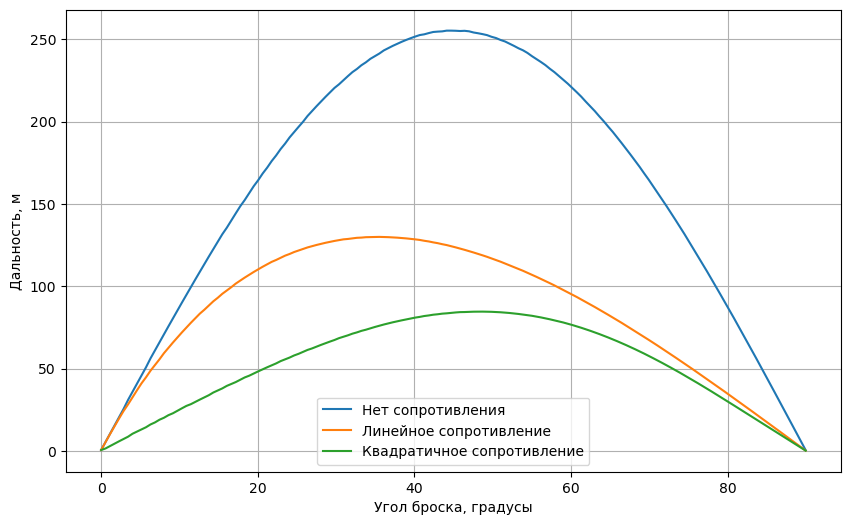

In [15]:
plt.figure(figsize=(10, 6))

for (k1, k2, name) in [(0.0, 0.0, 'Нет сопротивления'), (0.2, 0.0, 'Линейное сопротивление'), (0.0, 0.01, 'Квадратичное сопротивление')]:
    distances = []
    angles = np.arange(0.0, np.pi / 2, 0.01)
    for angle in angles:
        _, _, flight_distance, _, _ = solve(50, angle, k1, k2)
        distances.append(flight_distance)

    distances = np.array(distances)
    plt.plot(angles[:len(distances)] * 180 / np.pi, distances, label=name)

plt.xlabel('Угол броска, градусы')
plt.ylabel('Дальность, м')
plt.legend()
plt.grid(True)
plt.show()

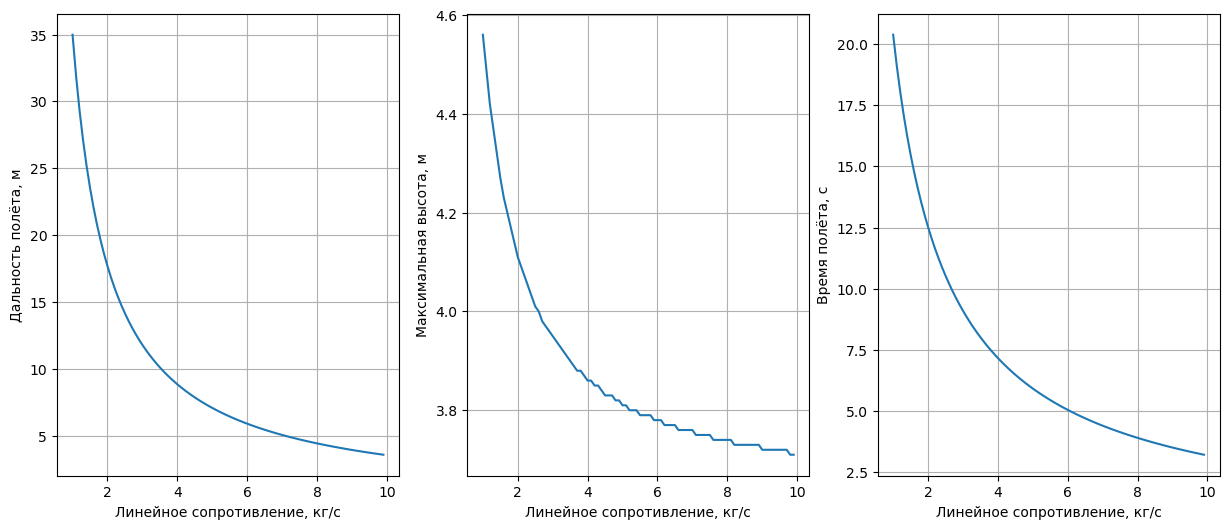

In [23]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))

ks = np.concat([np.arange(1.0, 10.0, 0.1)])
distances, heights, times = [], [], []
for k in ks:
    _, _, distance, height, time = solve(50, np.pi / 4, k, 0.0)

    distances.append(distance)
    heights.append(height)
    times.append(time)

distances = np.array(distances)
heights = np.array(heights)
times = np.array(times)

axes[0].plot(ks[:len(distances)], distances)
axes[0].set_ylabel('Дальность полёта, м')

axes[1].plot(ks[:len(heights)], heights)
axes[1].set_ylabel('Максимальная высота, м')

axes[2].plot(ks[:len(times)], times)
axes[2].set_ylabel('Время полёта, с')

for i in range(3):
    axes[i].set_xlabel('Линейное сопротивление, кг/с')
    axes[i].grid(True)

plt.show()

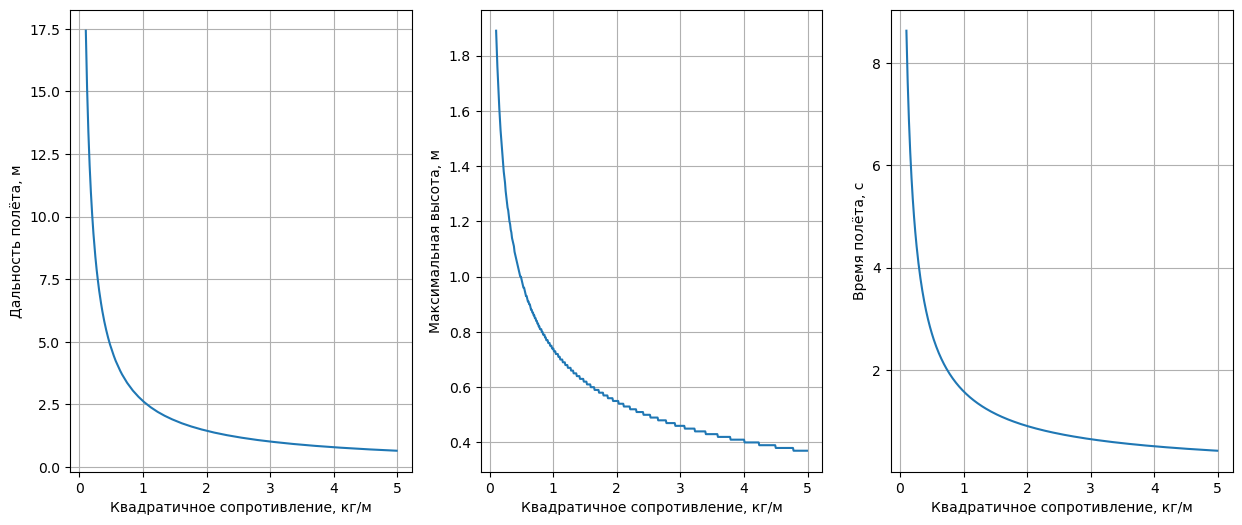

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))

ks = np.concat([np.arange(0.1, 5.0, 0.01)])
distances, heights, times = [], [], []
for k in ks:
    _, _, distance, height, time = solve(50, np.pi / 4, 0.0, k)

    distances.append(distance)
    heights.append(height)
    times.append(time)

distances = np.array(distances)
heights = np.array(heights)
times = np.array(times)

axes[0].plot(ks[:len(distances)], distances)
axes[0].set_ylabel('Дальность полёта, м')

axes[1].plot(ks[:len(heights)], heights)
axes[1].set_ylabel('Максимальная высота, м')

axes[2].plot(ks[:len(times)], times)
axes[2].set_ylabel('Время полёта, с')

for i in range(3):
    axes[i].set_xlabel('Квадратичное сопротивление, кг/м')
    axes[i].grid(True)
    axes[i].axis('equal') 

plt.show()

In [105]:
def curve_advance(state: np.ndarray, dt: float, k1: float, k2: float) -> np.ndarray:
    x, y, v, alpha = state

    a_n = g * np.cos(alpha) # resistance forces are purely tangential
    a_t = g * np.sin(alpha) + k1 * v + k2 * np.linalg.norm(v) * v # directed against velocity vector

    r = v * v / a_n
    omega = v / r

    alpha1 = alpha - omega * dt

    dx = r * np.sin(alpha) - r * np.sin(alpha1) # см. рисунок из пеинта
    dy = - r * np.cos(alpha) + r * np.cos(alpha1)

    # x1 = x + v * np.cos(alpha)
    # y1 = y + v * np.sin(alpha)

    return np.array([dx / dt, dy / dt, -a_t, -omega])

dt = 0.01
integrator = ode(lambda _, state: curve_advance(state, dt, 0.1, 0.0))
integrator.set_initial_value(np.array([0.0, 0.0, 50.0, np.pi / 4]))

states = []
while integrator.successful() and integrator.t < 10.0:
    x, y, v, alpha = integrator.integrate(integrator.t + dt)
    states.append((integrator.t, x, y, v, alpha))

![arc](M1_arc.png)

(np.float64(-10.806126245963625),
 np.float64(234.70832546091245),
 np.float64(-147.24269312101146),
 np.float64(61.01449443952274))

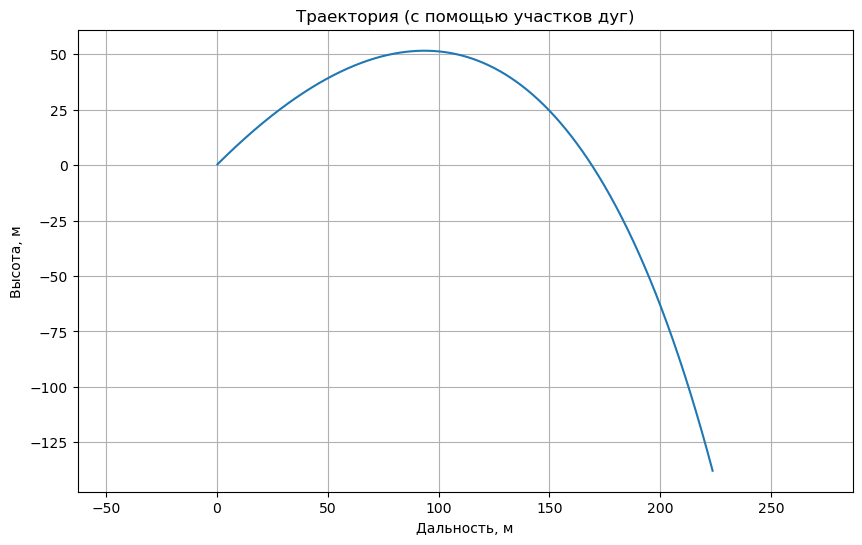

In [106]:
states_ = np.array(states).transpose()

plt.figure(figsize=(10, 6))
plt.plot(states_[1], states_[2])
plt.title('Траектория (с помощью участков дуг)')
plt.xlabel('Дальность, м')
plt.ylabel('Высота, м')
plt.grid(True)
plt.axis('equal')